# H2 — Mental-model Accuracy / Explicability (F1 / F2 / F3)

OpenMATB transparency study (content-constant, *wording-only* design). This
notebook covers **only hypothesis H2** — one half of the load-bearing H1/H2 pair
— as stated in the report (`Documents/Report/main.tex`, §3 and the *H2 —
Mental-model probe* measure):

> **H2 (contrastive form improves explicability).** Post-block mental-model
> accuracy is highest under the contrastive forms **F2 / F3**, even though the
> information content is identical across forms.

H2 is the **objective** counterpart to H1: where H1 asks whether the verbose form
*feels* more transparent (subjective explainability), H2 asks whether the
operator's mental model actually *updated* (objective explicability). The study's
core claim is that these move in **opposite** directions — F1 feels most
informative, yet F2/F3 leave the operator better calibrated.

**Design (from the study, see `project_3_study.pdf`).**

| Role | Variable | Detail |
|------|----------|--------|
| Independent variable | Explanation **form** | F1 verbose · F2 contrastive · F3 contrastive + actionable. **Within-subjects** — each participant sees all three (Latin-square counterbalanced), each paired with a different gauge set (A/B/C) so the probe cannot be answered from another block. |
| Primary DV | **Explicability composite** | `mm_explicability` ∈ [0, 1], the proportion of all probe items answered correctly. Higher = better-calibrated mental model. |
| Sub-scores | act · miss · close | `mm_act_accuracy` (did the aid act on X?), `mm_miss_accuracy` (did it fail to act on Y?), `mm_close_accuracy` (was there a close call on Z?). All **higher = better**. |

## How H2 is measured (the 3-question mental-model probe)

After each block — *before* the subjective items, to capture the model before
reflection contaminates it — three `genericscales` sliders probe the operator's
mental model. Each block, the aid **handles** one of its two active gauges (acts
on it; both near-misses land here) and **misses** the other (its only events are
the two unhandled failures), giving each active gauge one clean role. Every item
is a **yes/no question about one active gauge**, scored **offline against that
block's roles**:

- **`act`** — "Did the aid act on **X**?" Truth = X is the handled gauge. → `mm_act_accuracy`.
- **`miss`** — "Did the aid **fail to act** on **Y**?" Truth = Y is the missed gauge. → `mm_miss_accuracy`.
- **`close`** — "Was there a **close call** (near miss) on **Z**?" Truth = Z is the handled gauge. → `mm_close_accuracy`.

The act and miss questions always name *different* gauges, and which gauge each
question targets is **counterbalanced across blocks** so no fixed yes/no answer
pattern beats actually having tracked the block.

> **Why this replaces the old probe.** The earlier items asked for the *count* of
> misses / near-misses and the *overall reliability* — but by design those are the
> **same every block** (2 misses, 2 near-misses, ~78 %). Their correct answer was a
> fixed design constant, so a participant could score well by learning it once,
> without tracking the current block. The revised items are anchored to *which*
> active gauge the aid handled vs. abandoned this block, which only watching can
> reveal. Scoring lives in `matb_analysis/metrics_questionnaire.py`; the gauge
> roles are generated from the scenario itself (`_regenerate.py`) so they can't
> drift.

We report **descriptive statistics and visualisations**; the closing section
states the statistical approach and the test that applies to this design.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_metrics_table
from matb_analysis.discovery import find_study_sessions, DEFAULT_SESSIONS_DIR
from matb_analysis.validation import validate_sessions

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
FORM_LABELS = {"F1": "F1\nverbose", "F2": "F2\ncontrastive", "F3": "F3\n+actionable"}
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)

# Analyse the full simulated cohort (N=20, known ground truth); fall back to the
# default session_logs once real participants are collected. Whichever directory
# actually contains study sessions is used.
CANDIDATES = [Path.cwd().parent / "simulated", DEFAULT_SESSIONS_DIR]
DATA_DIR = next((d for d in CANDIDATES if find_study_sessions(d)), CANDIDATES[0])

## 1. Load the sessions and build the H2 metrics table

`find_study_sessions()` reads every study session under `DATA_DIR`. Each session
contributes three rows (one per form). The mental-model metrics are produced by
`build_metrics_table()`, which scores the five probe sliders against each block's
ground truth.

In [2]:
sessions = find_study_sessions(DATA_DIR)
print(f"Reading logs from: {DATA_DIR}")
print(f"Discovered {len(sessions)} study session(s).")

table = build_metrics_table(sessions)
H2_COLS = ["mm_explicability", "mm_act_accuracy", "mm_miss_accuracy", "mm_close_accuracy"]
(table[["participant", "form", "block"] + H2_COLS]
    .sort_values(["participant", "form"]).reset_index(drop=True))

Reading logs from: C:\Projects\HumanCenteredAI\analysis\simulated
Discovered 20 study session(s).


,participant,form,block,mm_explicability,mm_act_accuracy,mm_miss_accuracy,mm_close_accuracy
0,P01,F1,A,0.333333,0.0,1.0,0.0
1,P01,F2,B,1.000000,1.0,1.0,1.0
2,P01,F3,C,0.666667,1.0,0.0,1.0
3,P02,F1,A,1.000000,1.0,1.0,1.0
4,P02,F2,C,1.000000,1.0,1.0,1.0
5,P02,F3,B,1.000000,1.0,1.0,1.0
6,P03,F1,B,0.666667,1.0,0.0,1.0
7,P03,F2,A,1.000000,1.0,1.0,1.0
8,P03,F3,C,0.666667,0.0,1.0,1.0
9,P04,F1,C,0.333333,0.0,1.0,0.0


### 1b. Sanity check: design realised as intended

Each session is cross-checked against the Latin-square design (form ↔ block order,
panel form vs. briefing). Every participant should contribute exactly one block per
form, so that each form is probed against all three gauge sets equally across the
cohort. Any `ok = False` row must be resolved before trusting that session.

In [3]:
report = validate_sessions(sessions)
n_bad = int((~report["ok"]).sum()) if not report.empty else 0
print(f"{len(report)} session(s) validated; {n_bad} with design issues.")

print(f"\nParticipants: {table['participant'].nunique()}")
print("Blocks per form (should be equal):")
print(table["form"].value_counts().reindex(FORM_ORDER).to_string())
print("\nform x gauge-set (counterbalancing):")
print(pd.crosstab(table["form"], table["block"]).reindex(FORM_ORDER).to_string())

20 session(s) validated; 0 with design issues.

Participants: 20
Blocks per form (should be equal):
form
F1    20
F2    20
F3    20

form x gauge-set (counterbalancing):
block  A  B  C
form          
F1     6  6  8
F2     8  6  6
F3     6  8  6


## 2. Primary DV — explicability composite by form

Descriptive statistics of `mm_explicability` (the [0, 1] composite, higher = a
more accurate mental model) for each form. H2 predicts the contrastive forms
**F2 / F3** to sit **above** the verbose form F1.

In [4]:
def describe(df, col):
    g = df.groupby("form")[col]
    out = pd.DataFrame({
        "n_blocks": g.size(),
        "mean": g.mean(),
        "sd": g.std(),
        "median": g.median(),
        "min": g.min(),
        "max": g.max(),
    }).reindex(FORM_ORDER).round(3)
    return out

describe(table, "mm_explicability")

,n_blocks,mean,sd,median,min,max
form,,,,,,
F1,20,0.600,0.298,0.667,0.000,1.0
F2,20,0.917,0.183,1.000,0.333,1.0
F3,20,0.817,0.170,0.667,0.667,1.0


**Figure 1 — distribution of the explicability composite by form.** Box = median
and interquartile range; whiskers = range; each dot is one block. H2 predicts the
F2/F3 distributions to sit above F1 (higher = better-calibrated mental model).

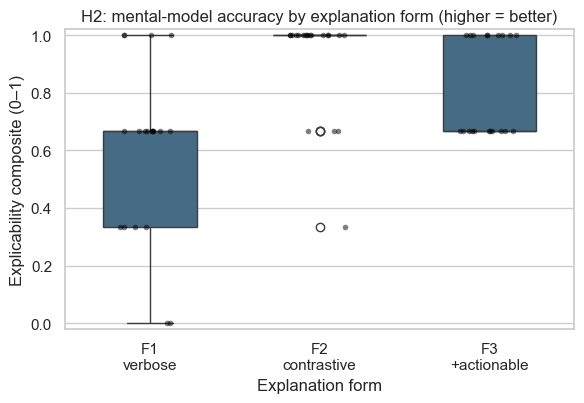

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.boxplot(data=table, x="form", y="mm_explicability", order=FORM_ORDER,
            color="#3b6e8f", width=0.55, ax=ax)
sns.stripplot(data=table, x="form", y="mm_explicability", order=FORM_ORDER,
              color="black", alpha=0.5, size=4, jitter=0.18, ax=ax)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Explicability composite (0–1)")
ax.set_xticks(range(len(FORM_ORDER)))
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_title("H2: mental-model accuracy by explanation form (higher = better)")
fig.tight_layout()
fig.savefig(OUT / "h2_explicability_by_form.png", dpi=150)
plt.show()

**Figure 2 — within-subject view.** Each grey line is one participant across the
three forms; the thick line is the mean. Because the design is within-subjects,
this shows whether *individuals* tend to build a more accurate model under F2/F3,
not just the group average.

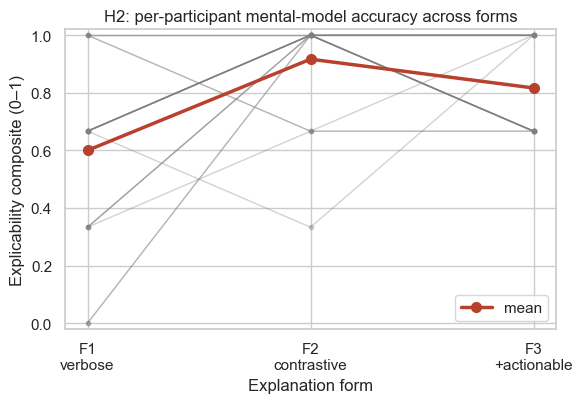

In [6]:
wide = table.pivot_table(index="participant", columns="form", values="mm_explicability")
wide = wide.reindex(columns=FORM_ORDER)

fig, ax = plt.subplots(figsize=(6, 4.2))
x = np.arange(len(FORM_ORDER))
for _, row in wide.iterrows():
    ax.plot(x, row.values, color="grey", alpha=0.35, marker="o", markersize=3,
            linewidth=1)
ax.plot(x, wide.mean(axis=0).values, color="#b8412e", marker="o", markersize=7,
        linewidth=2.5, label="mean")
ax.set_xticks(x)
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Explicability composite (0–1)")
ax.set_title("H2: per-participant mental-model accuracy across forms")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "h2_explicability_perparticipant.png", dpi=150)
plt.show()

## 3. Unpacking the composite — the three question types

The composite pools three yes/no questions per block. This section reports each
separately so an effect can be traced to its source — knowing which gauge the aid
**worked** (`act`), which it **abandoned** (`miss`), and where the **close call**
occurred (`close`):

- `mm_act_accuracy` — "did the aid act on X?" (**higher = better**).
- `mm_miss_accuracy` — "did the aid fail to act on Y?" (**higher = better**).
- `mm_close_accuracy` — "was there a close call on Z?" (**higher = better**).

Each is one item per block, so a form's score is the share of blocks answered
correctly. H2 predicts F2/F3 above F1 on all three.

In [7]:
SUBSCORES = ["mm_act_accuracy", "mm_miss_accuracy", "mm_close_accuracy"]
parts_desc = (table.groupby("form")[SUBSCORES]
                   .agg(["mean", "median", "std"])
                   .reindex(FORM_ORDER)
                   .round(3))
parts_desc

mm_act_accuracy               mm_miss_accuracy                \
                mean median    std             mean median    std   
form                                                                
F1              0.50    0.5  0.513              0.6    1.0  0.503   
F2              0.90    1.0  0.308              1.0    1.0  0.000   
F3              0.85    1.0  0.366              0.8    1.0  0.410   

     mm_close_accuracy                
                  mean median    std  
form                                  
F1                0.70    1.0  0.470  
F2                0.85    1.0  0.366  
F3                0.80    1.0  0.410

**Figure 3 — the three sub-scores by form.** All **higher = better**. H2 predicts
F2/F3 to sit **above** F1 on each — the contrastive panel makes the aid's
per-gauge behaviour easier to read off and remember.

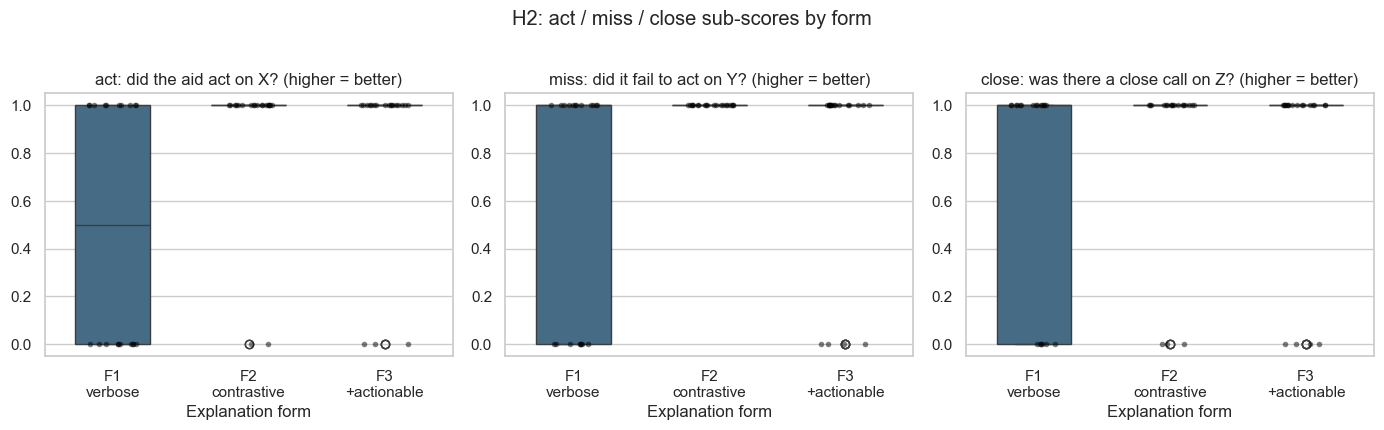

In [8]:
panels = [
    ("mm_act_accuracy", "act: did the aid act on X? (higher = better)"),
    ("mm_miss_accuracy", "miss: did it fail to act on Y? (higher = better)"),
    ("mm_close_accuracy", "close: was there a close call on Z? (higher = better)"),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (col, title) in zip(axes, panels):
    sns.boxplot(data=table, x="form", y=col, order=FORM_ORDER,
                color="#3b6e8f", width=0.55, ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER,
                  color="black", alpha=0.5, size=4, jitter=0.18, ax=ax)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Explanation form")
    ax.set_ylabel("")
    ax.set_xticks(range(len(FORM_ORDER)))
    ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
    ax.set_title(title)
fig.suptitle("H2: act / miss / close sub-scores by form", y=1.02)
fig.tight_layout()
fig.savefig(OUT / "h2_mentalmodel_by_form.png", dpi=150)
plt.show()

## 4. Compact summary table

One row per form, suitable for the report. H2 predicts the explicability composite
and all three sub-scores (act, miss, close) to **rise** from F1 to F2/F3.

In [9]:
SUMMARY_COLS = ["mm_explicability", "mm_act_accuracy", "mm_miss_accuracy", "mm_close_accuracy"]
summary = (table.groupby("form")[SUMMARY_COLS]
              .agg(["mean", "median", "std"])
              .reindex(FORM_ORDER)
              .round(3))
summary.to_csv(OUT / "h2_mental_model_summary_by_form.csv")
summary

mm_explicability               mm_act_accuracy                \
                 mean median    std            mean median    std   
form                                                                
F1              0.600  0.667  0.298            0.50    0.5  0.513   
F2              0.917  1.000  0.183            0.90    1.0  0.308   
F3              0.817  0.667  0.170            0.85    1.0  0.366   

     mm_miss_accuracy               mm_close_accuracy                
                 mean median    std              mean median    std  
form                                                                 
F1                0.6    1.0  0.503              0.70    1.0  0.470  
F2                1.0    1.0  0.000              0.85    1.0  0.366  
F3                0.8    1.0  0.410              0.80    1.0  0.410

## 5. Statistical analysis — descriptive focus

We report **descriptive statistics and visualisations** rather than a single
significance test, for two reasons tied to the measure and the study brief:

1. **Bounded, few-item composite.** The composite is the proportion correct over
   three binary items per block, so it takes only a handful of discrete values; the
   means, medians, per-participant trajectories (Fig. 2) and sub-score breakdown
   (Fig. 3) convey the pattern more faithfully than a single test statistic would
   at this sample size. Because the items' answers are counterbalanced across
   blocks, a constant-answer strategy cannot beat ~chance — the very strategy the
   old design-constant items rewarded — so any F2/F3-over-F1 gap reflects genuine
   per-block tracking.
2. **Deliberate, transparent inference.** The study brief cautions against
   over-interpreting modest sample sizes and against using unfamiliar tests, so we
   keep the inferential step explicit rather than reflexive.

**The test that fits this design.** Because the design is within-subjects with
three related conditions, the appropriate approach is a **repeated-measures ANOVA**
on the explicability composite (with sphericity checked) when it is approximately
normal, or a non-parametric **Friedman** omnibus followed by **Wilcoxon
signed-rank** post-hoc tests for the two planned, directional contrasts —
**F1 < F2** (contrastiveness) and **F2 < F3** (actionability) — with a Holm
correction and a rank-biserial effect size. The decisive test of the study's
thesis is the **H1 × H2 crossover**: a form × measure-type interaction on the
z-scored subjective-transparency (H1) and explicability (H2) scores, predicted to
run in *opposite* directions. The tidy table built above is the ready input for
that step.